# 02 · Visualisation

**Ce que fait ce notebook.** Avant d'entraîner quoi que ce soit, il répond à une question de
faisabilité : *les catégories se distinguent-elles dans les données, ou pas du tout ?*

On regarde trois choses : l'équilibre des classes, la quantité d'information disponible par
catégorie, et une **projection en deux dimensions** qui montre si les articles d'une même catégorie
se regroupent.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, BLEU_CLAIR, BLEU_FONCE, GRILLE = "#2a78d6", "#cde2fb", "#0d366b", "#e0dfdb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.size": 11,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE_2,
        "axes.edgecolor": GRILLE,
        "xtick.color": ENCRE_2,
        "ytick.color": ENCRE_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
print(f"racine du projet : {RACINE}")

racine du projet : /private/tmp/claude-501/-Users-trikwi-P15/f44c0be7-fdba-44bf-91a6-d59f2bf27089/scratchpad/build


In [2]:
from src.pipeline import LABEL_COL, TEXT_COL, load, split
from src.text import vectoriseur

df = load()
train, val, test = split(df)
categories = sorted(df[LABEL_COL].unique())
print(f"{len(df)} articles · {len(categories)} catégories")

1050 articles · 7 catégories


## 1 · Deux équilibres, deux verdicts

À gauche le nombre d'articles, à droite la longueur des descriptions. Le premier est parfait, le
second ne l'est pas du tout, et c'est le second qui compte pour un modèle.

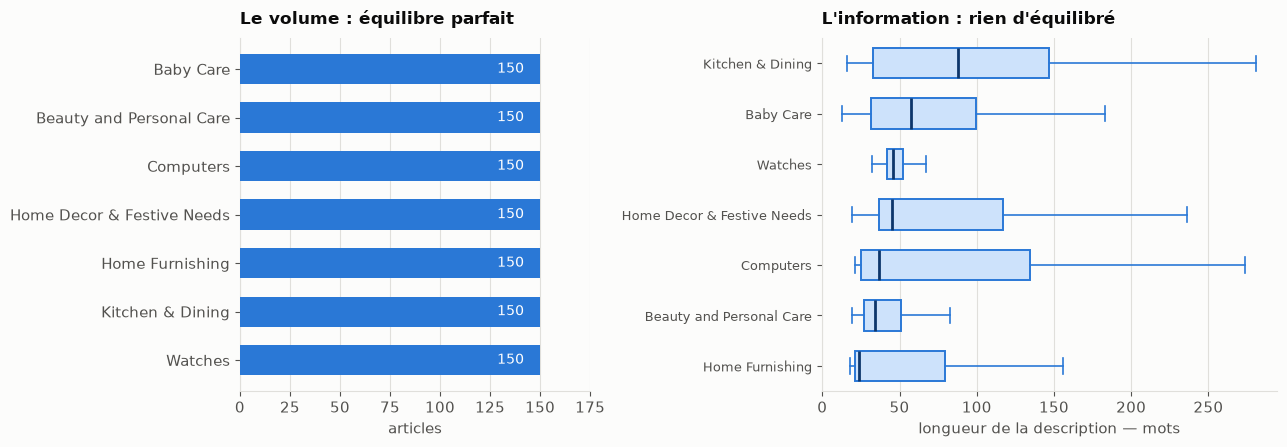

In [3]:
effectifs = df[LABEL_COL].value_counts().sort_index()
longueurs = df.assign(n=df[TEXT_COL].str.split().str.len())
ordre = longueurs.groupby(LABEL_COL)["n"].median().sort_values().index

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.3]})

a1.barh(effectifs.index[::-1], effectifs.values[::-1], color=BLEU, height=0.62, zorder=3)
for i, v in enumerate(effectifs.values[::-1]):
    a1.text(v - 8, i, str(v), va="center", ha="right", color="white", fontsize=10)
a1.set_xlim(0, 175)
a1.set_xlabel("articles")
a1.grid(axis="x", color=GRILLE, lw=0.8, zorder=0)
a1.set_title("Le volume : équilibre parfait", fontsize=12, fontweight="bold", loc="left", pad=10)

bp = a2.boxplot(
    [longueurs.loc[longueurs[LABEL_COL] == c, "n"] for c in ordre],
    orientation="horizontal",
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
for b in bp["boxes"]:
    b.set(facecolor=BLEU_CLAIR, edgecolor=BLEU, linewidth=1.4)
for partie in ("whiskers", "caps"):
    for w in bp[partie]:
        w.set(color=BLEU, linewidth=1.2)
for m in bp["medians"]:
    m.set(color=BLEU_FONCE, linewidth=2)
a2.set_yticklabels(ordre, fontsize=9.5)
a2.set_xlabel("longueur de la description — mots")
a2.grid(axis="x", color=GRILLE, lw=0.8, zorder=0)
a2.set_title("L'information : rien d'équilibré", fontsize=12, fontweight="bold", loc="left", pad=10)
plt.tight_layout()
plt.show()

*Home Furnishing* est décrit deux fois moins longuement que la médiane, *Kitchen & Dining* deux
fois plus. **Hypothèse à vérifier plus loin : les catégories les moins décrites seront les moins bien
classées.**

## 2 · Mots discriminants par catégorie

Le TF-IDF pondère un terme par sa fréquence dans un document **et** par sa rareté dans le corpus. En
moyennant ces poids par catégorie, on obtient les termes les plus caractéristiques de chacune.

C'est un contrôle de bon sens : si les termes qui remontent n'ont rien à voir avec la catégorie, il
faut s'inquiéter avant de modéliser.

In [4]:
vec = vectoriseur()
X = vec.fit_transform(train[TEXT_COL])
termes = np.array(vec.get_feature_names_out())
print(f"vocabulaire ajusté sur l'entraînement seulement : {len(termes)} termes")

for cat in categories:
    masque = (train[LABEL_COL] == cat).to_numpy()
    poids = np.asarray(X[masque].mean(axis=0)).ravel()
    top = termes[np.argsort(-poids)[:8]]
    print(f"\n{cat:28s} {' · '.join(top)}")

vocabulaire ajusté sur l'entraînement seulement : 4532 termes

Baby Care                    baby · cotton · girl · baby girl · details · fabric · baby boy · boy

Beauty and Personal Care     com buy · combo · flipkart com · com · flipkart · combo set · set online · set

Computers                    com genuine · usb · replacement · guarantee free · guarantee · day replacement · replacement guarantee · 30 day

Home Decor & Festive Needs   showpiece · cm · cm rs · cm best · best · best prices · prices free · delivery genuine

Home Furnishing              products free · com genuine · flipkart com · com · flipkart · abstract · single · buy

Kitchen & Dining             mug · ceramic · ceramic mug · kadhai · best · delivery genuine · prices free · best prices

Watches                      watch · analog · analog watch · great discounts · discounts genuine · india flipkart · discounts · men


Chaque liste est immédiatement reconnaissable. C'est le signe que la tâche est **lexicalement
séparable** : le vocabulaire d'une fiche produit porte l'essentiel de l'information de catégorie.

C'est aussi une prédiction : sur ce genre de texte, une représentation lexicale devrait bien se
comporter, peut-être mieux qu'un encodeur pré-entraîné.

## 3 · Projection en deux dimensions

On réduit les 4 500 dimensions du TF-IDF à deux, par une projection non linéaire (t-SNE), et on
colore par la **vraie** catégorie. Si les couleurs forment des groupes, le regroupement automatique
est possible.

> **Précaution de lecture.** t-SNE préserve le voisinage local, pas les distances globales. Les
> distances entre groupes éloignés ne veulent rien dire, et la forme des groupes non plus. On lit
> une seule chose : *les articles d'une même catégorie sont-ils voisins ?*

In [5]:
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE

# Réduction linéaire d'abord — pratique recommandée avant t-SNE sur matrice creuse.
svd = TruncatedSVD(n_components=50, random_state=42)
Z = svd.fit_transform(X)
print(f"variance expliquée par 50 composantes : {svd.explained_variance_ratio_.sum():.1%}")

proj = TSNE(n_components=2, random_state=42, perplexity=30, init="pca").fit_transform(Z)
print(f"projection : {proj.shape}")

variance expliquée par 50 composantes : 40.9%


projection : (735, 2)


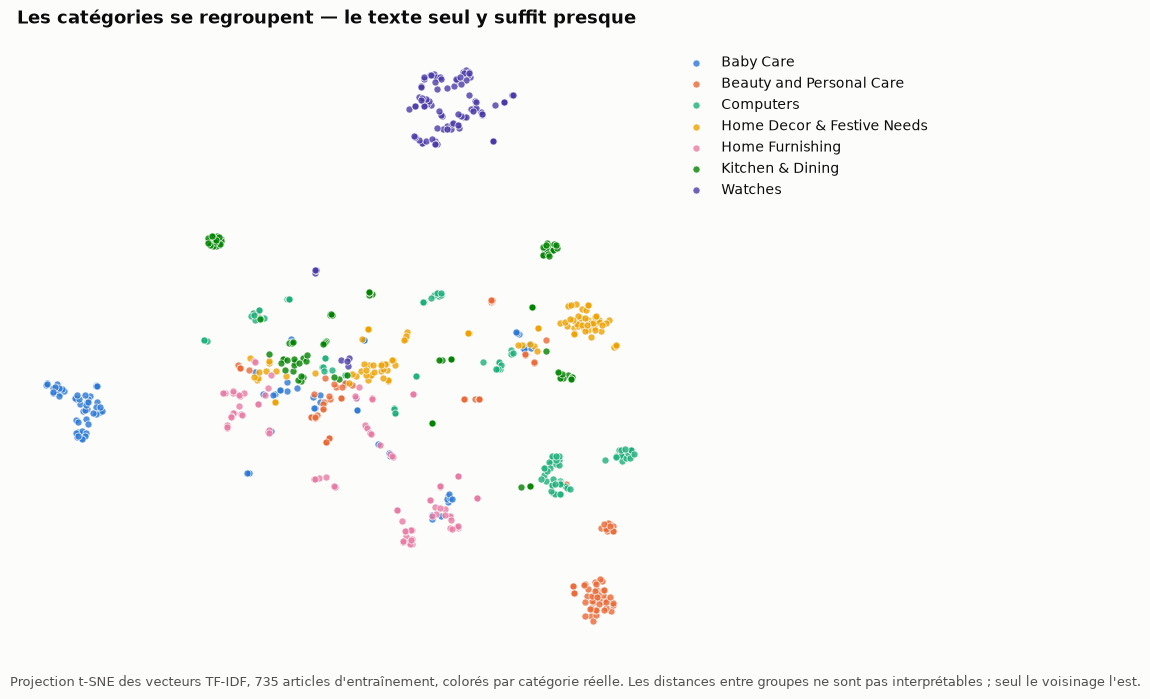

In [6]:
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]

fig, ax = plt.subplots(figsize=(9.5, 7))
for couleur, cat in zip(PALETTE, categories, strict=True):
    m = (train[LABEL_COL] == cat).to_numpy()
    ax.scatter(
        proj[m, 0],
        proj[m, 1],
        s=26,
        color=couleur,
        alpha=0.8,
        edgecolor=SURFACE,
        linewidth=0.6,
        label=cat,
        zorder=3,
    )
ax.set_xticks([])
ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)
ax.set_title(
    "Les catégories se regroupent — le texte seul y suffit presque",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=14,
)
fig.text(
    0.01,
    0.01,
    "Projection t-SNE des vecteurs TF-IDF, 735 articles d'entraînement, "
    "colorés par catégorie réelle. Les distances entre groupes ne sont pas "
    "interprétables ; seul le voisinage l'est.",
    fontsize=9,
    color=ENCRE_2,
)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

**Verdict de faisabilité : oui.** Les groupes sont visibles et majoritairement séparés. Deux
observations qui orientent la suite :

- *Computers* et *Watches* forment des îlots nets : vocabulaire très spécifique ;
- les catégories domestiques (*Home Furnishing*, *Home Decor*, *Kitchen & Dining*, *Baby Care*) se
  chevauchent dans la même région. Un rideau, un vase et un plat se décrivent avec les mêmes mots :
  matière, dimensions, couleur.

**C'est là que le texte va échouer, et c'est là que l'image aura une chance.**

## Sorties du carnet

| Constat | Conséquence pour la suite |
|---|---|
| Les catégories se regroupent visuellement | Le projet est faisable |
| Le vocabulaire est très discriminant | Une représentation lexicale devrait bien se comporter |
| Quatre catégories domestiques se chevauchent | C'est là qu'on attend les erreurs |
| L'information textuelle est inégale entre catégories | Les moins décrites seront les moins bien classées |

→ Notebook suivant : **03 · Modèles texte**, pour mesurer au lieu de deviner.